# UMAP DATA GENERATION

## Loading libraries and importing packages

In [31]:
import matplotlib.pyplot as plt  # Visualization library
import seaborn as sns
import numpy as np               # Basic mathematics
import os                        # OS options in line with Python
import pandas as pd              # Dataframes library
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.pipeline import make_pipeline
import umap  # pip install umap-learn
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, MaxAbsScaler, Normalizer
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import Circle
import math
import matplotlib.ticker as ticker
import datetime
from sklearn.model_selection import train_test_split

# 1. Function definition

In [32]:
def mad_centroid(group):
    median = np.median(group, axis=0)
    mad = np.median(np.abs(group - median), axis=0)
    return median

In [33]:
def cluster_CentroidRadius_DensityPercent (X_umap, y, density_th, percent_th):

    classes = np.unique(y)
    umap_clusters = {value: X_umap[y == value] for value in classes} #Dicctionari amb 1:{coordenades de csPCa = 1} i 0:{coordenades de csPCA = 0}
    class_counts = {value: np.sum(y == value) for value in np.unique(y)}

    #Compute centroids
    centroids = {value: mad_centroid(umap_clusters[value]) for value in classes} #Diccionari amb 1:{centroide de csPCa = 1} i 0:{centroide de csPCa = 0}

    distances_to_centroids = []

    for point, value in zip(X_umap, y):
        centroid = centroids[value]
        distance = np.linalg.norm(point - centroid)  # Euclidean distance
        distances_to_centroids.append(distance)
    distances_to_centroids = np.array(distances_to_centroids)  

    radius = {}
    for value in classes:
        percent = 0
        rad = 1
        density = 20
        while not (percent >= percent_th and density <= density_th) :
            rad_def = rad
            rad += 1
            cluster_indices = (y == value)
            cluster_distances = distances_to_centroids[cluster_indices]
            n_samples_rad = np.sum(cluster_distances <= rad)
            area = math.pi*rad**2
            density = n_samples_rad/area
            percent = n_samples_rad/class_counts[value]
        radius[value] = rad_def        

    return centroids, radius

## Load data

In [4]:
#cd

/home/usuaris.new/carla.lazaro


In [5]:
#cd "PICAI_data"

/home/usuaris.new/carla.lazaro/PICAI_data


In [34]:
picai = pd.read_csv('marksheet_minimal.csv') 
print('The original features are:')
picai_columns=list(picai.columns)
print(list(picai_columns))
picai_psa = picai.drop(["psad", "psad_computed"], axis=1)
picai_col = picai_psa.columns
picai_psa.info()

The original features are:
['patient_age', 'psad', 'psa', 'psad_computed', 'prostate_volume', 'case_csPCa']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_age      1500 non-null   float64
 1   psa              1460 non-null   float64
 2   prostate_volume  1473 non-null   float64
 3   case_csPCa       1500 non-null   float64
dtypes: float64(4)
memory usage: 47.0 KB


In [35]:
#KNN imputation 
knn_imputer = KNNImputer(n_neighbors=10)
picai_psa_imputed = knn_imputer.fit_transform(picai_psa.copy())
picai_psa_imputed = pd.DataFrame(picai_psa_imputed, columns = picai_col )

picai_psa_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_age      1500 non-null   float64
 1   psa              1500 non-null   float64
 2   prostate_volume  1500 non-null   float64
 3   case_csPCa       1500 non-null   float64
dtypes: float64(4)
memory usage: 47.0 KB


## UMAP visualization

In [36]:
random_state = 23

In [37]:
X_picai, y_picai = picai_psa_imputed.drop(["case_csPCa"], axis=1), picai_psa_imputed[["case_csPCa"]].values.flatten()

norm_pipe = make_pipeline(StandardScaler()).fit(X_picai)
X_norm = norm_pipe.transform(X_picai.copy())
manifold_norm = umap.UMAP(random_state=random_state).fit(X_norm, y_picai)

X_umap_norm = manifold_norm.transform(X_norm)

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


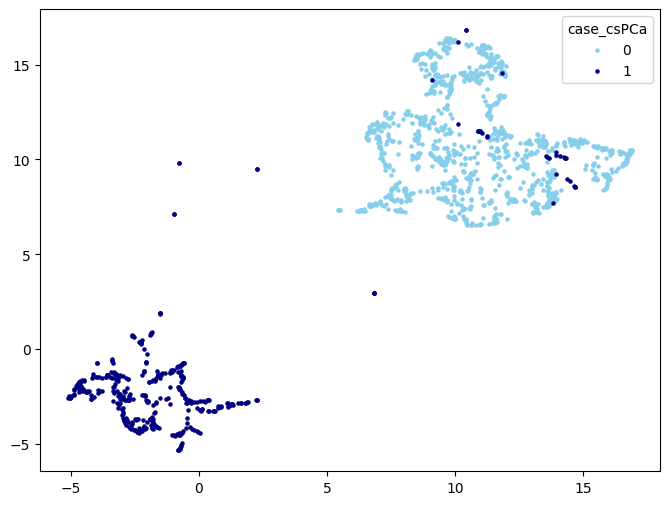

In [38]:
plt.figure(figsize=(8, 6))

class_0_idx = y_picai == 0.0
plt.scatter(X_umap_norm[class_0_idx, 0], X_umap_norm[class_0_idx, 1], c='skyblue', label='0', s=5)

class_1_idx = y_picai == 1.0
plt.scatter(X_umap_norm[class_1_idx, 0], X_umap_norm[class_1_idx, 1], c='navy', label='1', s=5)

plt.legend(title="case_csPCa")

plt.show()

## Split database between reference and incomplete

In [39]:
#Split the dataframe into reference data and incomplete data. We aim to maintain the proportion of the target value by using the 'stratity' parameter of the funtion.

reference_df, incomplete_df  = train_test_split(
    picai_psa_imputed, 
    test_size=1000, #remainder size
    stratify=picai_psa_imputed['case_csPCa'], 
    random_state = random_state+5
)

print('Shape of the reference data:', reference_df.shape, '. Mean value of the case_csPCa variable:', reference_df['case_csPCa'].mean())
print('Shape of the incomplete data:',incomplete_df.shape, '. Mean value of the case_csPCa variable:', incomplete_df['case_csPCa'].mean())

Shape of the reference data: (500, 4) . Mean value of the case_csPCa variable: 0.284
Shape of the incomplete data: (1000, 4) . Mean value of the case_csPCa variable: 0.283


In [40]:
# Divide the dataframe between the target feature and the rest

X_ref_df, y_ref = reference_df.drop(["case_csPCa"], axis=1), reference_df[["case_csPCa"]].values.flatten()
X_ref = X_ref_df.to_numpy()

norm_pipe = make_pipeline(StandardScaler()).fit(X_ref)

X_inc_df, y_inc = incomplete_df.drop(["case_csPCa"], axis=1), incomplete_df[["case_csPCa"]].values.flatten()
X_inc = X_inc_df.to_numpy()

In [41]:
# Select the missing feature. In this case, the chosen feature is 'patient_age'. 

X_incomplete_df, age_missing = X_inc_df.drop(["patient_age"], axis=1), X_inc_df[["patient_age"]].values.flatten()
X_incomplete = X_incomplete_df.to_numpy()

## Reference UMAP

In [42]:
X_reference_norm = norm_pipe.transform(X_ref_df)
manifold = umap.UMAP(random_state).fit(X_reference_norm, y_ref)
umap_ref = manifold.transform(X_reference_norm)

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [43]:
#Calculate the centroids coordinates and cluster radius of reference data for a certain density threshold.

percent_th = 0.9
density_th = 4

centroids_coord, cluster_radius = cluster_CentroidRadius_DensityPercent (umap_ref, y_ref, density_th, percent_th)

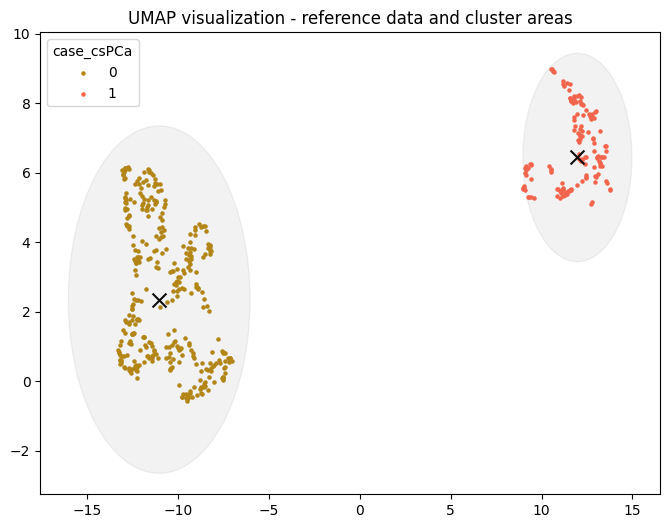

In [56]:
random_state = 23


plt.figure(figsize=(8, 6))

class_0_idx = y_ref == 0.0
plt.scatter(umap_ref[class_0_idx, 0], umap_ref[class_0_idx, 1], c='darkgoldenrod', label='0', s=5)

class_1_idx = y_ref == 1.0
plt.scatter(umap_ref[class_1_idx, 0], umap_ref[class_1_idx, 1], c='tomato', label='1', s=5)

plt.legend(title="case_csPCa")
plt.title('UMAP visualization - reference data and cluster areas')

for value, centroid in centroids_coord.items():
        plt.scatter(centroid[0], centroid[1], c='black', marker='x', s=100)
        circle = Circle(centroid, cluster_radius[value] , color='grey', alpha=0.1, label=f'Density = {density_th}')
        plt.gca().add_patch(circle)  
           
plt.savefig('A_central_umap_ref.png', dpi=200, bbox_inches='tight') 
plt.show()

## M range definition for each variable

#### Quantization pre process for PSA feature

In [45]:
psa_values = X_ref[:, 1]

def custom_round(value):
    rounded_value = round(value * 2) / 2
    return rounded_value


sorted_psa_values = np.sort(psa_values)
rounded_values = np.array([custom_round(val) for val in sorted_psa_values])


In [46]:
minmax_psa = [0, 100]
step_psa = 0.5

#Obtain min and max values of each feature
min_values = np.min(X_ref, axis=0)
max_values = np.max(X_ref, axis=0)

minmax_age = [min_values[0], max_values[0]]
minmax_pvol = [min_values[2], max_values[2]]

step_age = 1
step_pvol = 1

minmax_v = [minmax_age, minmax_psa, minmax_pvol]
step_v = [step_age, step_psa, step_pvol]

## Feature Disparcity 

In [47]:
#Compute the feature disparcity of the reference data in order to define the relibility score for synthetic data. 
#Compute the difference between the mean feature value of the k-nearest neighbours and the value of each sample. 

n_neigh = 10
nbrs = NearestNeighbors(n_neighbors=n_neigh, radius = 0.5, algorithm='auto').fit(umap_ref)
distances, indices = nbrs.kneighbors(umap_ref) #Obtain the distances and the indices of the closest neighbours on the reference UMAP

miss_idx = 0
mean_neighbor_age = np.mean(X_ref[indices, miss_idx], axis=1)
sample_age = X_ref[:,miss_idx]
feature_dis_age = abs(mean_neighbor_age - sample_age)

miss_idx = 1
mean_neighbor_psa = np.mean(X_ref[indices, miss_idx], axis=1)
sample_psa = X_ref[:,miss_idx]
feature_dis_psa = abs(mean_neighbor_psa - sample_psa)

miss_idx = 2
mean_neighbor_pvol = np.mean(X_ref[indices, miss_idx], axis=1)
sample_pvol = X_ref[:,miss_idx]
feature_dis_pvol = abs(mean_neighbor_pvol - sample_pvol)



In [48]:
eps_age = round(np.mean(feature_dis_age))
eps_psa = round(np.mean(feature_dis_psa))
eps_pvol = round(np.mean(feature_dis_pvol))
print('Epsilon for patient age:', eps_age)
print('Epsilon for PSA:', eps_psa)
print('Epsilon for prostate volume:', eps_pvol)
eps_v = [eps_age, eps_psa, eps_pvol]

Epsilon for patient age: 1
Epsilon for PSA: 4
Epsilon for prostate volume: 6


## Partially synthetic data generation

### Function

In [49]:
def synthetic_data_umap (
    uncompleted_data, #DataFrame with one missing feature
    X_reference, #Reference DataFrame
    y_reference, #Reference output variable
    percent_th, #Percentage of cluster samples inside the cluster area
    density_th,#Cluster area density of samples
    n_neigh, #Number of considered neighbours for reliability score
    sel_reliability, #Chosen reliability for chosen generated samples
    minmax,#Min and max values of the M range
    step,#Step on the M range
    eps, #Epsilon 
    miss_feat, #Name of the column with the missing feature
    index, 
    random_val):

    #COMPUTE REFERENCE UMAP
    X_ref = X_reference.to_numpy() #Array with the reference data
    norm_pipe = make_pipeline(StandardScaler()).fit(X_ref) #Normalization pipe
    X_reference_norm = norm_pipe.transform(X_reference)
    manifold = umap.UMAP(random_state=random_val).fit(X_reference_norm, y_reference)
    umap_reference = manifold.transform(X_reference_norm)

    #Calculate the CENTROIDS coordinates and cluster radius of reference data for a certain density threshold and percentage threshold
    centroids_coord, cluster_radius = cluster_CentroidRadius_DensityPercent (umap_reference, y_reference, density_th, percent_th)

    min_value = minmax[0]
    max_value = minmax[1]

    synthetic_data = pd.DataFrame()
    synthetic_data_feature = pd.DataFrame()
    uncompleted_data.insert(0, miss_feat, 0)

    #loop for all the values in M range
    for target_value in np.arange(min_value, max_value+1, step):

        now = datetime.datetime.now()
        print('Target value:', target_value, now.time())

        generated_data = uncompleted_data
        generated_data[miss_feat] = target_value
        X_gen_norm = norm_pipe.transform(generated_data) #Normalize the array of uncompleted data
        umap_gen = manifold.transform(X_gen_norm) #UMAP coordinates

        #DATA VALIDATION:
        validation_vec = [] 
        cluster_vector = [] #Equivalent to case_csPCA for this set of data with target_age. If nan, means the sample does not have cluster validation

        # STEP 1: CLUSTER VALIDATION
        # Compute distances to centroids for all points
        distances_to_centroids = np.array([np.linalg.norm(umap_gen - centroid, axis=1) for centroid in centroids_coord.values()])

        # Find index of closest centroid for each point
        closest_centroid_indices = np.argmin(distances_to_centroids, axis=0)

        # Initialize cluster_vector with np.nan
        cluster_vector = np.full(len(umap_gen), np.nan)

        # Update cluster_vector for points within cluster radius
        for idx, min_distance in enumerate(np.min(distances_to_centroids, axis=0)):
            closest_centroid = closest_centroid_indices[idx]
            if min_distance < cluster_radius[closest_centroid]:
                cluster_vector[idx] = closest_centroid
                generated_data_cluster = generated_data.copy()
                generated_data_cluster['case_csPCa'] = cluster_vector   

        #Get the positions that did not passa cluster validation. Position 'True' means the sample did not pass cluster validation
        non_validated_pos = np.isnan(cluster_vector) 


        # STEP 2: AGE RELIAVILITY
        nbrs = NearestNeighbors(n_neighbors=n_neigh, radius = 0.5, algorithm='auto').fit(umap_reference)
        distances, indices = nbrs.kneighbors(umap_gen) #Obtain the distances and the indices of the closest neighbours on the reference UMAP
        mean_neighbor_feature = np.mean(X_ref[indices, index], axis=1) #Compute the mean value of the feature for the nearest nesighbours
        feature_distances = np.array([abs(mean_feature - target_value) for mean_feature in mean_neighbor_feature])

        feature_reliabilities = np.where(
        feature_distances <= eps, 1,
        np.where(feature_distances <= 2*eps, 0.9,
                 np.where(feature_distances <= 3*eps, 0.8,
                          np.where(feature_distances <= 4*eps, 0.7,
                                   np.where(feature_distances <= 5*eps, 0.6,
                                            np.where(feature_distances <= 6*eps, 0.5, 0.2))))))  # Compute age reliabilities

        feature_reliabilities[non_validated_pos] = np.nan


        valid_indexes = np.where(feature_reliabilities == sel_reliability)[0]
        synthetic_data_targetValue = generated_data_cluster.iloc[valid_indexes]

        #Add the synthetic data generated with every target age
        synthetic_data_feature = pd.concat([synthetic_data_feature, synthetic_data_targetValue], ignore_index=True)

    #Add the synthetic data generated for every missing feature
    synthetic_data = pd.concat([synthetic_data, synthetic_data_feature], ignore_index=True)
    #Print the results in a file        
    output_file = 'synthetic_data.xlsx'
    synthetic_data.to_excel(output_file, index=False)
    return(synthetic_data)
print('Validated synthetic samples:', len(synth_data))


Validated synthetic samples: 13736


In [50]:
synth_data = synthetic_data_umap (
    uncompleted_data = X_incomplete_df,
    X_reference = X_ref_df, 
    y_reference = y_ref,
    percent_th = 0.9, 
    density_th = 4,
    n_neigh = 10, 
    sel_reliability = 1, 
    minmax = minmax_age,
    step = step_age,
    eps = eps_age, 
    miss_feat = "patient_age", 
    index = 0, 
    random_val = 23 )

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Target value: 35.0 21:48:27.131015


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Target value: 36.0 21:48:27.587576


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


...

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Target value: 86.0 21:48:51.538970


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Target value: 87.0 21:48:52.015583


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Synthetic data visualization

In [51]:
#Features and target variable
X_picai_synt, y_picai_synth = synth_data.drop(["case_csPCa"], axis=1), synth_data[["case_csPCa"]].values.flatten()

norm_pipe_s = make_pipeline(StandardScaler()).fit(X_picai_synt)
X_picai_norm_synt = norm_pipe_s.transform(X_picai_synt.copy())

manifold_norm_synt = umap.UMAP(random_state=random_state).fit(X_picai_norm_synt, y_picai_synth)
umap_picai_synt = manifold_norm_synt.transform(X_picai_norm_synt)

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


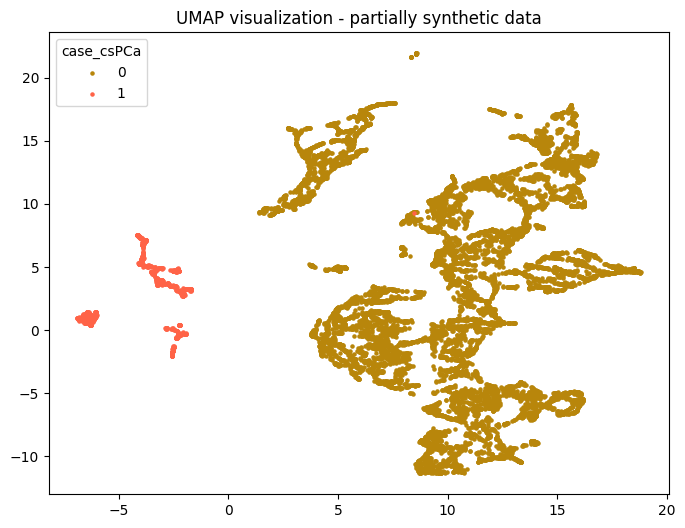

In [55]:
plt.figure(figsize=(8, 6))

class_0_idx = y_picai_synth == 0.0
plt.scatter(umap_picai_synt[class_0_idx, 0], umap_picai_synt[class_0_idx, 1], c='darkgoldenrod', label='0', s=5)

class_1_idx = y_picai_synth == 1.0
plt.scatter(umap_picai_synt[class_1_idx, 0], umap_picai_synt[class_1_idx, 1], c='tomato', label='1', s=5)

plt.legend(title="case_csPCa")
plt.title('UMAP visualization - partially synthetic data')
plt.savefig('A_central_umap_synth.png', dpi=200, bbox_inches='tight')
plt.show()

Compute fidelity and utility

In [53]:
# Fidelity
from scipy.stats import ks_2samp

ks_results = {}
for feature in ['patient_age', 'psa', 'prostate_volume']:
    stat, _ = ks_2samp(picai_psa_imputed[feature], synth_data[feature])
    ks_results[feature] = stat
print('KS distance per feature:', ks_results)
print('Mean KS distance:', sum(ks_results.values()) / len(ks_results))

KS distance per feature: {'patient_age': np.float64(0.22483847796544365), 'psa': np.float64(0.08675131042516016), 'prostate_volume': np.float64(0.061218404193360554)}
Mean KS distance: 0.12426939752798812


In [54]:
# Utility 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# Real test set (held out from real data)
X_real, y_real = picai_psa_imputed.drop('case_csPCa', axis=1), picai_psa_imputed['case_csPCa']
_, X_test_real, _, y_test_real = train_test_split(X_real, y_real, test_size=0.3, stratify=y_real, random_state=42)

# TSTR: train on synthetic, test on real
X_synth, y_synth = synth_data.drop('case_csPCa', axis=1), synth_data['case_csPCa']
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_synth, y_synth)
y_pred = clf.predict(X_test_real)
y_proba = clf.predict_proba(X_test_real)[:, 1]
print('TSTR AUC:', roc_auc_score(y_test_real, y_proba))
print('TSTR F1:', f1_score(y_test_real, y_pred))
print('TSTR Accuracy:', accuracy_score(y_test_real, y_pred))

TSTR AUC: 0.6896711440481705
TSTR F1: 0.43781094527363185
TSTR Accuracy: 0.7488888888888889
